In [2]:
%load_ext autoreload
%autoreload 2

import os

os.chdir("../../")

In [3]:
import pandas as pd
from pathlib import Path

data_dir = Path("data/ai-ai-experiments")
fps = [fp for fp in data_dir.iterdir() if fp.is_file() and fp.suffix == ".csv"]

In [ ]:
# transcripts = []

# for fp in fps:
#     df = pd.read_csv(fp)
#     for round_ix in range(1, 5):
#         col_name = f"referential_task.{round_ix}.group.ai_messages"
#         messages = eval(df[col_name].values[0])
#         transcript = "\n\n".join([f'[{msg["sender_role"]}]: {msg["text"]}' for msg in messages])
#         transcripts.append(
#             {
#                 "fp": fp.name,
#                 "round_ix": round_ix,
#                 "transcript": transcript,
#                 "# turns": len(messages)//2,
#             }
#         )
# transcripts_df = pd.DataFrame(transcripts)

In [8]:
# transcripts_df.groupby(["fp", "round_ix"])["# turns"].mean()

In [9]:
transcripts_fp = "data/clean_transcripts_gpt5_to_gpt5_various_reasonings.csv"

if os.path.exists(transcripts_fp):
    transcripts_df = pd.read_csv(transcripts_fp)
    print("Loaded existing transcripts.")

else:
    transcripts = []

    for fp in fps:
        df = pd.read_csv(fp)
        for round_ix in range(1, 5):
            col_name = f"referential_task.{round_ix}.group.ai_messages"
            messages = eval(df[col_name].values[0])
            transcript = "\n\n".join([f'[{msg["sender_role"]}]: {msg["text"]}' for msg in messages])
            transcripts.append(
                {
                    "fp": fp.name,
                    "round_ix": round_ix,
                    "transcript": transcript
                }
            )
    transcripts_df = pd.DataFrame(transcripts)
    transcripts_df.to_csv(transcripts_fp, index=False)
    print(f"Created new transcripts and saved to {transcripts_fp}.")
    
transcripts_df

Loaded existing transcripts.


,fp,round_ix,transcript,llm_extracted_object_descriptions_GPT_5
0,5.2-low-reasoning.csv,1,[director]: Basket 1: a lidded wicker basket s...,"{\n ""object_#1"": ""a lidded wicker basket sh..."
1,5.2-low-reasoning.csv,2,[director]: Basket 1 (top-left): a rectangular...,"{\n ""object_#1"": ""rectangular picnic-hamper..."
2,5.2-low-reasoning.csv,3,[director]: Basket 1 (top-left): a rectangular...,"{\n ""object_#1"": ""a rectangular handled bas..."
3,5.2-low-reasoning.csv,4,[director]: Basket 1 (top-left): a very shallo...,"{\n ""object_#1"": ""a very shallow OVAL tray-..."
4,5.2-high-reasoning.csv,1,[director]: Basket 1 is the light-tan wicker b...,"{\n ""object_#1"": ""light-tan wicker basket s..."
5,5.2-high-reasoning.csv,2,[director]: Basket 1 (top-left): a boxy rectan...,"{\n ""object_#1"": ""boxy rectangular picnic-h..."
6,5.2-high-reasoning.csv,3,[director]: Basket 1 (top-left) is the open re...,"{\n ""object_#1"": ""open rectangular basket w..."
7,5.2-high-reasoning.csv,4,[director]: Basket 1 (top-left) is a very shal...,"{\n ""object_#1"": ""very shallow, low-sided O..."
8,5.2-medium-reasoning.csv,1,[director]: Basket 1: a light-tan wicker baske...,"{\n ""object_#1"": ""light-tan wicker basket s..."
9,5.2-medium-reasoning.csv,2,[director]: Basket 1 (top-left): a light tan r...,"{\n ""object_#1"": ""light tan rectangular wic..."


In [ ]:


transcripts_df["parsed_llm_response"] = transcripts_df["llm_extracted_object_descriptions_GPT_5"].apply(parse_llm_response) 
transcripts_df

,fp,round_ix,transcript,llm_extracted_object_descriptions_GPT_5,parsed_llm_response
0,5.2-low-reasoning.csv,1,[director]: Basket 1: a lidded wicker basket s...,"{\n ""object_#1"": ""a lidded wicker basket sh...",{'object_#1': 'a lidded wicker basket shaped l...
1,5.2-low-reasoning.csv,2,[director]: Basket 1 (top-left): a rectangular...,"{\n ""object_#1"": ""rectangular picnic-hamper...",{'object_#1': 'rectangular picnic-hamper style...
2,5.2-low-reasoning.csv,3,[director]: Basket 1 (top-left): a rectangular...,"{\n ""object_#1"": ""a rectangular handled bas...",{'object_#1': 'a rectangular handled basket wi...
3,5.2-low-reasoning.csv,4,[director]: Basket 1 (top-left): a very shallo...,"{\n ""object_#1"": ""a very shallow OVAL tray-...",{'object_#1': 'a very shallow OVAL tray-like b...
4,5.2-high-reasoning.csv,1,[director]: Basket 1 is the light-tan wicker b...,"{\n ""object_#1"": ""light-tan wicker basket s...",{'object_#1': 'light-tan wicker basket shaped ...
5,5.2-high-reasoning.csv,2,[director]: Basket 1 (top-left): a boxy rectan...,"{\n ""object_#1"": ""boxy rectangular picnic-h...","{'object_#1': 'boxy rectangular picnic-hamper,..."
6,5.2-high-reasoning.csv,3,[director]: Basket 1 (top-left) is the open re...,"{\n ""object_#1"": ""open rectangular basket w...",{'object_#1': 'open rectangular basket with cl...
7,5.2-high-reasoning.csv,4,[director]: Basket 1 (top-left) is a very shal...,"{\n ""object_#1"": ""very shallow, low-sided O...","{'object_#1': 'very shallow, low-sided OVAL wi..."
8,5.2-medium-reasoning.csv,1,[director]: Basket 1: a light-tan wicker baske...,"{\n ""object_#1"": ""light-tan wicker basket s...",{'object_#1': 'light-tan wicker basket shaped ...
9,5.2-medium-reasoning.csv,2,[director]: Basket 1 (top-left): a light tan r...,"{\n ""object_#1"": ""light tan rectangular wic...",{'object_#1': 'light tan rectangular wicker pi...


In [11]:
object_filename_map = {
  "rounds": [
    {
      "round": 1,
      "baskets": [
        "076.png", "001.png", "015.png", "009.png", "022.png", "033.png",
        "012.png", "040.png", "037.png", "019.png", "065.png", "017.png"
      ]
    },
    {
      "round": 2,
      "baskets": [
        "015.png", "037.png", "001.png", "022.png", "040.png", "076.png",
        "033.png", "019.png", "012.png", "065.png", "017.png", "009.png"
      ]
    },
    {
      "round": 3,
      "baskets": [
        "012.png", "009.png", "033.png", "076.png", "017.png", "037.png",
        "001.png", "040.png", "022.png", "019.png", "065.png", "015.png"
      ]
    },
    {
      "round": 4,
      "baskets": [
        "019.png", "022.png", "076.png", "012.png", "065.png", "001.png",
        "037.png", "015.png", "033.png", "009.png", "017.png", "040.png"
      ]
    },
    {
      "fullList": [
        "076.png", "001.png", "015.png", "009.png", "022.png", "033.png",
        "012.png", "040.png", "037.png", "019.png", "065.png", "017.png",
        "005.png", "039.png", "057.png", "081.png", "077.png", "078.png"
      ]
    }
  ]
}
object_filename_map = object_filename_map["rounds"]
type(object_filename_map), len(object_filename_map)

(list, 5)

In [12]:
extracted_descriptions = []
cols = ["pair_id", "round_ix", "transcript", "object_ix", "filename", "object_description"]

for _, row in transcripts_df.iterrows():
    pair_id = row["fp"]
    round_ix = row["round_ix"]
    transcript = row["transcript"]
    description_dict = row["parsed_llm_response"]
    for i, key in enumerate(description_dict):
        object_ix = i+1
        
        if f"object_#{object_ix}" != key:
            print(
                f"Warning: Expected object_#{object_ix} but got {key} in pair {pair_id}, round {round_ix}"
            )
            continue
        
        filename = object_filename_map[round_ix - 1]["baskets"][i]
        object_description = description_dict.get(key, None)
        extracted_descriptions.append(
            {
                "pair_id": pair_id,
                "round_ix": round_ix,
                "transcript": transcript,
                "object_ix": object_ix,
                "filename": filename,
                "object_description": object_description,
            }
        )

In [13]:
def get_reasoning_effort(model_name):
    if "none" in model_name:
        return 0
    elif "low" in model_name:
        return 1
    elif "medium" in model_name:
        return 2
    elif "high" in model_name:
        return 3
    else:
        return -1  # Unknown reasoning effort

extracted_descriptions_df = pd.DataFrame(extracted_descriptions)
extracted_descriptions_df["reasoning_effort"] = extracted_descriptions_df["pair_id"].apply(get_reasoning_effort)
extracted_descriptions_df.head()

,pair_id,round_ix,transcript,object_ix,filename,object_description,reasoning_effort
0,5.2-low-reasoning.csv,1,[director]: Basket 1: a lidded wicker basket s...,1,076.png,a lidded wicker basket shaped like a duck in s...,1
1,5.2-low-reasoning.csv,1,[director]: Basket 1: a lidded wicker basket s...,2,001.png,"a deep, rounded bucket-style wicker basket wit...",1
2,5.2-low-reasoning.csv,1,[director]: Basket 1: a lidded wicker basket s...,3,015.png,a rectangular picnic-style wicker basket with ...,1
3,5.2-low-reasoning.csv,1,[director]: Basket 1: a lidded wicker basket s...,4,009.png,a shallow oval/boat-shaped basket with a singl...,1
4,5.2-low-reasoning.csv,1,[director]: Basket 1: a lidded wicker basket s...,5,022.png,"a low, rectangular tote-style wicker basket wi...",1


In [14]:
extracted_descriptions_df.pair_id.unique(), extracted_descriptions_df["reasoning_effort"].unique()

(array(['5.2-low-reasoning.csv', '5.2-high-reasoning.csv',
        '5.2-medium-reasoning.csv', '5.2-none-reasoning.csv'], dtype=object),
 array([1, 3, 2, 0]))

In [15]:
extracted_descriptions_piv = extracted_descriptions_df.pivot(
    index=["pair_id", "filename"],
    columns="round_ix",
    values="object_description"
)
extracted_descriptions_piv

round_ix                                                                           1  \
pair_id                  filename                                                      
5.2-high-reasoning.csv   001.png   a deep, round bucket-shaped wicker basket with...   
                         009.png   an oval, boat-shaped open basket with a single...   
                         012.png   a rectangular open basket with one arch handle...   
                         015.png   a boxy rectangular picnic-hamper basket with O...   
                         017.png   a medium light-brown open wicker tote with a s...   
                         019.png   a very shallow, round tray-like basket with a ...   
                         022.png   an open rectangular, fairly shallow honey-brow...   
                         033.png   a round, lidded wicker basket made to look lik...   
                         037.png   a tall, straight-sided cylindrical wicker hamp...   
                         040.png   the small, squat oval/rounded-rectangle basket...   
                         065.png   a large, wide round tub-shaped basket (deeper ...   
                         076.png   light-tan wicker basket shaped like a DUCK in ...   
5.2-low-reasoning.csv    001.png   a deep, rounded bucket-style wicker basket wit...   
                         009.png   a shallow oval/boat-shaped basket with a singl...   
                         012.png   a rectangular basket with a single arched hand...   
                         015.png   a rectangular picnic-style wicker basket with ...   
                         017.png   a small squat rounded handbag-like basket in h...   
                         019.png   a very shallow ROUND tray basket with one arch...   
                         022.png   a low, rectangular tote-style wicker basket wi...   
                         033.png   the round lidded wicker basket that looks like...   
                         037.png   a tall, straight-sided cylindrical wicker hamp...   
                         040.png   a squat, rounded-oval “barrel” basket in dark ...   
                         065.png   a wide, round open tub/bucket basket with NO a...   
                         076.png   a lidded wicker basket shaped like a duck in s...   
5.2-medium-reasoning.csv 001.png   rounded, bucket-shaped warm-brown basket, very...   
                         009.png   small, shallow OVAL (boat-shaped) basket, very...   
                         012.png   rectangular basket with a single arched handle...   
                         015.png   tan rectangular picnic-style basket, hinged li...   
                         017.png   medium reddish/orange-brown wicker basket, rou...   
                         019.png   very shallow ROUND tray-basket, single arched ...   
                         022.png   low, rectangular medium-brown basket, very thi...   
                         033.png   round, lidded light-tan basket shaped like a C...   
                         037.png   tall, upright cylindrical wicker hamper in med...   
                         040.png   squat, dark gray/charcoal woven basket, thick ...   
                         065.png   short, wide tub-shaped brown basket, TWO thick...   
                         076.png   light-tan wicker basket shaped like a mouse/ra...   
5.2-none-reasoning.csv   001.png   deep, rounded bucket-style wicker basket, very...   
                         009.png   light cream/tan oval wicker basket, one arched...   
                         012.png   wide rectangular basket with a single arched h...   
                         015.png   boxy rectangular picnic basket with a tall han...   
                         017.png   a medium-light brown open wicker basket with O...   
                         019.png   very shallow, round tray-like wicker basket wi...   
                         022.png   squat, rectangular open basket, very thick twi...   
                         033.png   round

In [16]:
from src.data.utils import pretty_print


pretty_print(extracted_descriptions_piv.sample(5))

,round_ix,1,2,3,4
pair_id,filename,,,,
5.2-medium-reasoning.csv,009.png,"small, shallow OVAL (boat-shaped) basket, very light/cream wicker, single arched handle, handle has noticeable wrapped pale/white bands, small darker/reddish accents at the sides, very light cream oval with the little reddish wraps where the handle meets the sides","medium reddish/orange-brown basket, VERY open/see-through vertical slat sides (you can clearly see through it), one smooth arched handle the same color as the basket, not a dark handle, not a thick rope-twist","small OVAL wicker basket, one arched handle, handle has very noticeable pale/white wrapped sections (like tape), little reddish/brown wraps where it attaches on the sides, rim is a bit darker than the body, very light cream/near-white","small, shallow OVAL light/cream wicker basket, ONE arched handle, handle has very noticeable pale/white wrapped bands, small reddish/maroon wraps right where the handle meets the sides"
5.2-none-reasoning.csv,009.png,"light cream/tan oval wicker basket, one arched handle, handle has small colored wrap accents (reddish) near where it meets the sides, whole basket looks paler than most others, very light cream oval, little reddish wraps right where the handle meets the sides","a medium-light brown open wicker basket, ONE arched handle, a very distinctive V-shaped notch/dip in the front rim (like a little smile), The sides are fairly open lattice (not tight weave)","a small pale cream/tan OVAL wicker basket, ONE arched handle, the handle has a light/white wrap near the top, tiny reddish wrap/tie accents where the handle meets the sides, white/light wrap near the TOP of the handle, little reddish tie wraps are visible at BOTH handle attachment points, one of the palest/cream baskets in the set","very light cream/tan OVAL basket with ONE arched handle, small reddish wrap/tie accents right where the handle meets the sides (on both sides), very pale cream oval with ONE handle, small reddish tie wraps where the handle meets the sides, NOT a white/light wrap near the top of the handle, just the reddish ties at the bases"
5.2-high-reasoning.csv,022.png,"an open rectangular, fairly shallow honey-brown basket with a single high arch handle that looks thick and twisted like a rope, No lid, the color is pretty uniform (no green paneling), the shallow rectangular honey-brown one with the thick twisted/rope-like arch handle (no green paneling)","shallow, low-sided rectangular/squarish honey-brown basket, ONE high arch handle that’s thick and clearly twisted like a rope, open top, no lid","shallow, low-sided rectangular honey/golden-brown basket, ONE very thick twisted “rope” arch handle, open (no lid), looks tray-like compared to the deeper totes","small, boxy RECTANGULAR honey/golden-brown basket, open top, ONE very thick BRAIDED/rope-like arch handle, The weave looks like a tight checkerboard/square pattern, No lid and no green coloring, open-top (no lid), not the green-sided rectangle, not the lidded picnic hamper"
5.2-low-reasoning.csv,065.png,"a wide, round open tub/bucket basket with NO arched handle—instead it has two short “ear” handles on the sides at the rim, The side weave is a noticeable diagonal/chevron pattern, a thicker rim and darker-looking interior, wide tub with side ear-handles (not the tall cylinder)","wide, round open tub/bucket basket, NO arched handle, two short side “ear” handles at the rim, The sides have a clear diagonal/chevron weave pattern, a thicker rim (interior looks darker)","the VERY shallow round tray basket, a single arched handle, light tan/blonde, a super obvious spiral/coil pattern across the base, the flattest round tray, you can see the spiral across most of the base","a wide, round open tub basket, NO arched handle—only two small side “ear” handles at the rim, sides have a clear diagonal/chevron weave pattern"
5.2-none-reasoning.csv,001.png,"deep, rounded bucket-style wicker basket, very dark brown/black smooth arched handle, b

In [17]:
round_cols = [1, 2, 3, 4]


extracted_descriptions_piv_agg = (
    extracted_descriptions_piv
    .groupby('pair_id')[round_cols]
    .agg(lambda x: ' '.join(x.dropna().astype(str)))
    .reset_index()
)

extracted_descriptions_piv_agg

round_ix,pair_id,1,2,3,4
0,5.2-high-reasoning.csv,"a deep, round bucket-shaped wicker basket with...","deep, round bucket/bowl-shaped wicker basket, ...","very DEEP, bulbous round/bucket-shaped wicker ...","deep ROUND bucket/bowl basket, not rectangular..."
1,5.2-low-reasoning.csv,"a deep, rounded bucket-style wicker basket wit...","deep, round bucket/bowl-shaped wicker basket, ...","a deep round bucket/bowl basket, a very thick ...","a deep, rounded bucket/bowl wicker basket, a s..."
2,5.2-medium-reasoning.csv,"rounded, bucket-shaped warm-brown basket, very...",deep round bowl/bucket-shaped brown wicker bas...,"deep ROUND brown bucket-shaped basket, very th...","deep ROUND brown bucket-shaped basket, very th..."
3,5.2-none-reasoning.csv,"deep, rounded bucket-style wicker basket, very...","a very round, pot/cauldron-shaped wicker baske...","a very round, cauldron/pot-shaped wicker baske...","very round, cauldron/pot-shaped wicker basket,..."


In [18]:
from src.data.utils import pretty_print


pretty_print(extracted_descriptions_piv_agg.sample(2))

round_ix,pair_id,1,2,3,4
2,5.2-medium-reasoning.csv,"rounded, bucket-shaped warm-brown basket, very dark (almost black) thick arched handle, slightly lighter band around the rim, handle is much darker than the basket body small, shallow OVAL (boat-shaped) basket, very light/cream wicker, single arched handle, handle has noticeable wrapped pale/white bands, small darker/reddish accents at the sides, very light cream oval with the little reddish wraps where the handle meets the sides rectangular basket with a single arched handle, body is distinctly green/teal with vertical striping, orange-brown trim/rim, braided decorative band along the top edge, green/teal vertically striped one with orange-brown trim tan rectangular picnic-style basket, hinged lid that’s partly open/tilted up, tall central upright handle/strap, not a simple arched handle, lid is clearly propped open so you can see inside medium reddish/orange-brown wicker basket, rounded-oval/rounded-rectangular, noticeably OPEN/see-through sides (vertical slat/spoke look), one smooth arched handle the same color as the basket, not a dark handle, not a twisted rope handle very shallow ROUND tray-basket, single arched handle across it, base shows a clear spiral/coil weave pattern (like a coiled circle), flat, shallow round tray with the spiral base low, rectangular medium-brown basket, very thick twisted rope-like arched handle, it’s boxy and wide, no green stripes, thick braided/rope-like handle, no green striping round, lidded light-tan basket shaped like a CAT face (front-facing) on the top, stitched whiskers, a little pink nose, small ear bumps, full front-facing cat face tall, upright cylindrical wicker hamper in medium-brown, open at the top, TWO small loop handles on opposite sides right near the rim, not a big arched handle, tall straight-sided cylinder with two small loop handles near the rim, not the short wide tub squat, dark gray/charcoal woven basket, thick dark arched handle, subtle lighter/pale banding near the base/rim, two-tone gray look short, wide tub-shaped brown basket, TWO thick side handles sticking up (like little ears), chunky diagonal/zigzag weave band around the middle, squat, wide tub with TWO thick side handles (no single arch handle), the zigzag/diagonal band around the middle is clearly visible light-tan wicker basket shaped like a mouse/rat in side view, oval body with a pointed snout facing right and a little bead-like eye, curved strap/handle along the top/back, unlike the round cat-face one, side-view mouse/rat with the snout pointing right (not the round cat face)","deep round bowl/bucket-shaped brown wicker basket, THICK very dark (almost black) arched handle, noticeably lighter tan band around the rim/top, handle is nearly black, lighter band all around the rim medium reddish/orange-brown basket, VERY open/see-through vertical slat sides (you can clearly see through it), one smooth arched handle the same color as the basket, not a dark handle, not a thick rope-twist rectangular basket with a single arched handle, whole body is distinctly green/teal with vertical striping, orange-brown trim/rim, braided decorative band right along the top edge light tan rectangular wicker picnic/sewing basket, hinged lid that’s clearly flipped partly open (you can see inside), tall upright central handle/strap, NOT a simple arched handle, a single tall center strap small, shallow OVAL/boat-shaped basket in very light cream/blond wicker, ONE arched handle, little wrapped accents where the handle attaches to the rim (small darker/reddish wraps), Not round and not rectangular, reddish wraps are just at the two handle-attachment points, the rest is very pale cream very shallow ROUND tray-basket with a single arched handle across it, the base has a really obvious spiral/coil pattern (like a coiled circle), basically a flat, shallow round tray with that clear spiral/coil center, not a deep round basket low, wide rectangular honey-brown basket, very THICK twiste

In [22]:
from src.evals.red import compute_red_metrics


df_items, df_summary = compute_red_metrics(extracted_descriptions_piv_agg)
df_summary

,RALR_mean,R2LR_mean,R3LR_mean,R4LR_mean,LRMM_mean,RALO_mean,R4LO_mean
0,0.178984,0.23461,0.205568,0.096776,0.583333,0.786911,0.793974


In [23]:
df_items

round_ix,pair_id,1,2,3,4,len_RED1,len_RED2,len_RED3,len_RED4,RALR,R2LR,R3LR,R4LR,LRMM,RALO,R4LO
0,5.2-high-reasoning.csv,"a deep, round bucket-shaped wicker basket with...","deep, round bucket/bowl-shaped wicker basket, ...","very DEEP, bulbous round/bucket-shaped wicker ...","deep ROUND bucket/bowl basket, not rectangular...",626,429,369,547,0.283813,0.314696,0.410543,0.126198,0.666667,0.776160,0.807818
1,5.2-low-reasoning.csv,"a deep, rounded bucket-style wicker basket wit...","deep, round bucket/bowl-shaped wicker basket, ...","a deep round bucket/bowl basket, a very thick ...","a deep, rounded bucket/bowl wicker basket, a s...",437,278,390,352,0.221968,0.363844,0.107551,0.194508,0.666667,0.785389,0.795455
2,5.2-medium-reasoning.csv,"rounded, bucket-shaped warm-brown basket, very...",deep round bowl/bucket-shaped brown wicker bas...,"deep ROUND brown bucket-shaped basket, very th...","deep ROUND brown bucket-shaped basket, very th...",377,375,293,349,0.100796,0.005305,0.222812,0.074271,0.666667,0.803083,0.788265
3,5.2-none-reasoning.csv,"deep, rounded bucket-style wicker basket, very...","a very round, pot/cauldron-shaped wicker baske...","a very round, cauldron/pot-shaped wicker baske...","very round, cauldron/pot-shaped wicker basket,...",381,284,350,384,0.109361,0.254593,0.081365,-0.007874,0.333333,0.783011,0.784360


In [60]:
df_items["reasoning_effort"] = df_items["pair_id"].apply(get_reasoning_effort)
df_items[["reasoning_effort", "RALR", "R4LR", "LRMM", "RALO", "R4LO"]].corr()

round_ix,reasoning_effort,RALR,R4LR,LRMM,RALO,R4LO
round_ix,,,,,,
reasoning_effort,1.000000,0.582965,0.426309,0.774597,-0.032191,0.791208
RALR,0.582965,1.000000,0.715760,0.521144,-0.713115,0.954961
R4LR,0.426309,0.715760,1.000000,0.817015,-0.143248,0.638604
LRMM,0.774597,0.521144,0.817015,1.000000,0.226669,0.621712
RALO,-0.032191,-0.713115,-0.143248,0.226669,1.000000,-0.580486
R4LO,0.791208,0.954961,0.638604,0.621712,-0.580486,1.000000


In [62]:
df_items, df_summary = compute_red_metrics(extracted_descriptions_piv_agg, group_cols=["pair_id"])
df_summary

,pair_id,RALR_mean,R4LR_mean,LRMM_mean,RALO_mean,R4LO_mean
0,5.2-high-reasoning.csv,0.283813,0.126198,0.666667,0.776160,0.807818
1,5.2-low-reasoning.csv,0.221968,0.194508,0.666667,0.785389,0.795455
2,5.2-medium-reasoning.csv,0.100796,0.074271,0.666667,0.803083,0.788265
3,5.2-none-reasoning.csv,0.109361,-0.007874,0.333333,0.783011,0.784360


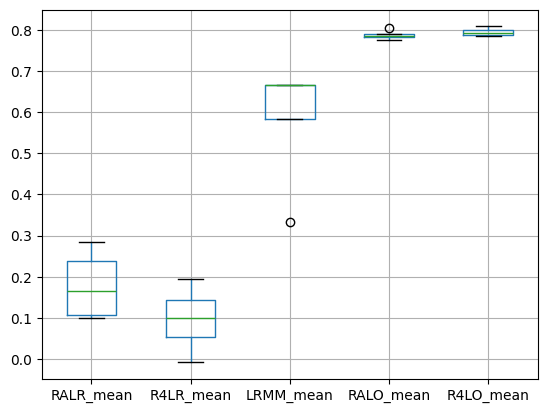

In [63]:
df_items, df_summary = compute_red_metrics(extracted_descriptions_piv_agg, group_cols=["pair_id"])

import matplotlib.pyplot as plt
df_summary.boxplot(column=["RALR_mean", "R4LR_mean", "LRMM_mean", "RALO_mean", "R4LO_mean"])
plt.show()

In [21]:
df_items, df_summary = compute_red_metrics(extracted_descriptions_piv)
df_summary

,RALR_mean,R2LR_mean,R3LR_mean,R4LR_mean,LRMM_mean,RALO_mean,R4LO_mean
0,0.151095,0.209658,0.180784,0.062843,0.513889,0.637812,0.691289


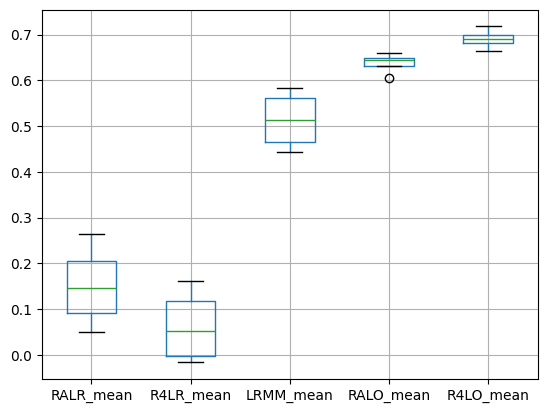

In [65]:
df_items, df_summary = compute_red_metrics(extracted_descriptions_piv, group_cols=["pair_id"])

import matplotlib.pyplot as plt
df_summary.boxplot(column=["RALR_mean", "R4LR_mean", "LRMM_mean", "RALO_mean", "R4LO_mean"])
plt.show()